# Client test

In [1]:
from services.simulation_service import simulate_circuit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import time

In [2]:
def dict_builder(nq, clb, initial_state, algorithm, runner_mode, noise_model, shots):
    initial_instructions = []
    for c, i in zip(initial_state, range(nq)):
        if c == '1':
            initial_instructions.append({"name": "X", "qubits": [i]})
    
    if runner_mode == 'shot': algorithm.append({"name": "MEASURE_ALL"})

    instructions = initial_instructions + algorithm
    
    return {
        "name": "Testing",
        "num_qubits": nq,
        "num_clbits": clb,
        "instructions": instructions,
        "runner_mode": runner_mode,
        "noise_model": noise_model,
        "shots": shots
    }

In [3]:
nq = 4
clb = 0
initial_state = '1110'
runner_mode = 'shot'
noise_model = 'depolarizing'
shots = 1024

algorithm_instructions = [
                            #{"name": "H", "qubits": [0]},
                            #{"name": "CX", "qubits": [0,1]},
                            #{"name": "CX", "qubits": [0,2]},
                            #{"name": "CX", "qubits": [0,3]},
                            #{"name": "HALF_ADD", "qubits": [0,1,2,3]},
                            {"name": "FULL_ADD", "qubits": [0,1,2,3]},
                            #{"name": "OLD_FULL_ADD", "qubits": [0,1,2,3,4,5,6,7]},
                        ]
dicccionary = dict_builder(nq, clb, initial_state, algorithm_instructions, runner_mode, noise_model, shots)

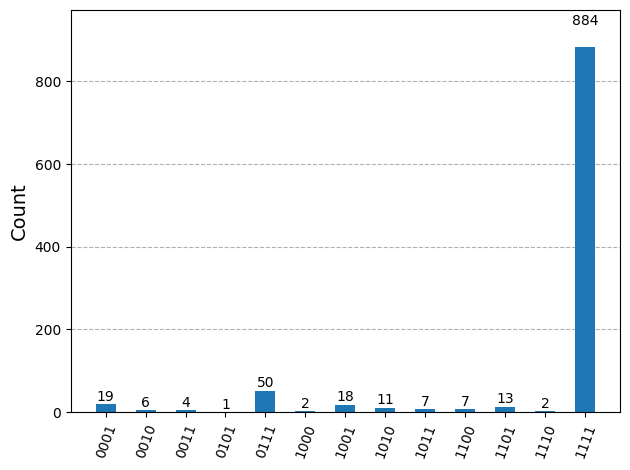

In [4]:
result = simulate_circuit(dicccionary, time.time())

counts = result.get('output').get('results')

counts = {k: abs(v) for k, v in counts.items() }

plot_histogram(counts)
#print(counts)

## Circuit Visualization

In [5]:
from services.circuit_service import build_circuit_from_dict

In [6]:
qc = build_circuit_from_dict(dicccionary)

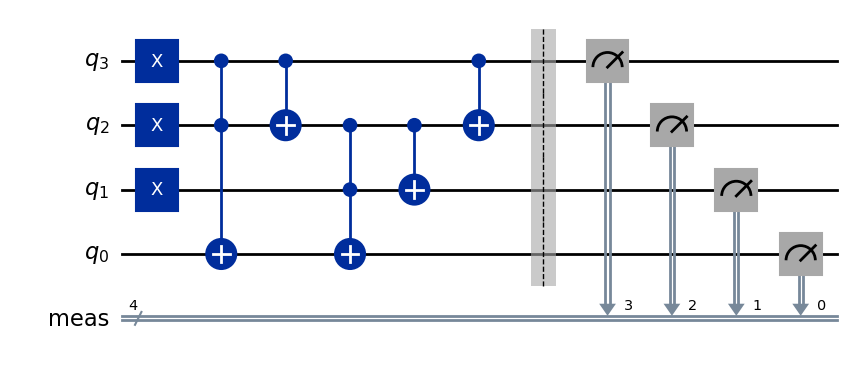

In [7]:
qc.draw('mpl', reverse_bits=True)

# Initialize states

In [8]:

from matplotlib.pylab import sqrt
nq = 2
clb = 0
initial_state = ''
runner_mode = 'statevector'
noise_model = 'depolarizing'
shots = 1024

initial_vector = [sqrt(0.7),sqrt(0.2),sqrt(0.1),0] # 100% state 2 

algorithm_instructions = [
                            {"name": "INITIALIZE", "qubits": [0,1], "params": initial_vector},                              
                        ]
dicccionary = dict_builder(nq, clb, initial_state, algorithm_instructions, runner_mode, noise_model, shots)

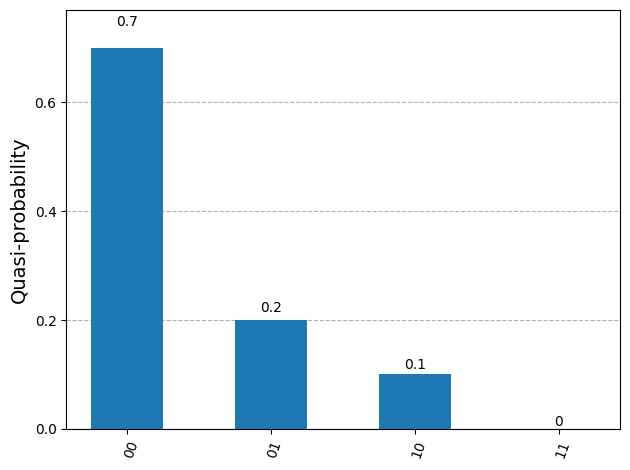

In [9]:
result = simulate_circuit(dicccionary, time.time())

counts = result.get('output').get('results')

counts = {k: abs(v)**2 for k, v in counts.items()}

plot_histogram(counts)

# Quantum furier transform

In [15]:
import numpy as np


nq = 5
N = 2**nq

t = np.linspace(0, 1, N, endpoint=False)

frecuencies = [3, 8]

signal = np.sin(2 * np.pi * frecuencies[0] * t) + 0.5 * np.sin(2 * np.pi * frecuencies[1] * t)

n_signal = signal / np.linalg.norm(signal)

clb = 0
initial_state = ''
runner_mode = 'shot'
noise_model = ''
shots = 1024

algorithm_instructions = [
                          {"name": "INITIALIZE", "qubits": list(range(nq)), "params": n_signal},
                          {"name": "QFT", "qubits": list(range(nq))}
                        ]
dicccionary = dict_builder(nq, clb, initial_state, algorithm_instructions, runner_mode, noise_model, shots)

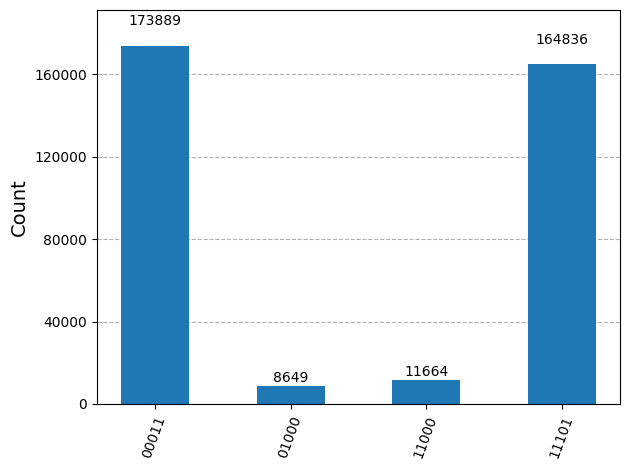

In [ ]:
results = simulate_circuit(dicccionary, time.time())

counts = results.get('output').get('results')
counts = {k: abs(v)**2 for k, v in counts.items()}

plot_histogram(counts)
print(counts)